#**Health Insurance Cost Prediction using Machine Learning**

##**Problem Statement**

Health insurance cost prediction has become an important challenge for insurance companies and healthcare providers. Accurately estimating the medical cost of policyholders helps insurers manage financial risk, determine fair premium pricing, and improve decision-making processes.

The objective of this project is to develop a machine learning model that can analyze historical health insurance data and accurately predict insurance costs based on factors such as age, gender, BMI, smoking habits, blood pressure, diabetes condition, exercise routine, number of dependents, occupation, city, and hereditary diseases.

####This project aims to:

- Identify patterns between customer profiles and insurance costs  
- Perform data preprocessing and feature engineering  
- Build and compare multiple regression models  
- Evaluate performance using MAE, RMSE, and R² Score  
- Select the best-performing model  
- Support premium planning and risk assessment

This system helps automate cost estimation and improve decision-making in the health insurance industry.

In [ ]:
from google.colab import files
uploaded = files.upload()
print(uploaded)

Saving 1651277648862_healthinsurance.csv to 1651277648862_healthinsurance.csv
{'1651277648862_healthinsurance.csv': b'age,sex,weight,bmi,hereditary_diseases,no_of_dependents,smoker,city,bloodpressure,diabetes,regular_ex,job_title,claim\r\n60,male,64,24.3,NoDisease,1,0,NewYork,72,0,0,Actor,13112.6\r\n49,female,75,22.6,NoDisease,1,0,Boston,78,1,1,Engineer,9567\r\n32,female,64,17.8,Epilepsy,2,1,Phildelphia,88,1,1,Academician,32734.2\r\n61,female,53,36.4,NoDisease,1,1,Pittsburg,72,1,0,Chef,48517.6\r\n19,female,50,20.6,NoDisease,0,0,Buffalo,82,1,0,HomeMakers,1731.7\r\n42,female,89,37.9,NoDisease,0,0,AtlanticCity,78,0,0,Dancer,6474\r\n18,male,59,23.8,NoDisease,0,0,Portland,64,0,0,Singer,1705.6\r\n21,male,52,26.8,NoDisease,0,0,Cambridge,74,1,0,Actor,1534.3\r\n63,male,55,,NoDisease,0,0,Hartford,70,1,0,Dancer,13390.6\r\n40,female,69,29.6,NoDisease,0,0,Springfield,64,1,1,DataScientist,5910.9\r\n51,female,50,33,EyeDisease,0,1,Syracuse,0,1,0,Police,44400.4\r\n59,female,68,36.5,NoDisease,1,0,Baltim

# **Data Preprocessing**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('/content/1651277648862_healthinsurance.csv')

In [ ]:
df.head()

,age,sex,weight,bmi,hereditary_diseases,no_of_dependents,smoker,city,bloodpressure,diabetes,regular_ex,job_title,claim
0,60.0,male,64,24.3,NoDisease,1,0,NewYork,72,0,0,Actor,13112.6
1,49.0,female,75,22.6,NoDisease,1,0,Boston,78,1,1,Engineer,9567.0
2,32.0,female,64,17.8,Epilepsy,2,1,Phildelphia,88,1,1,Academician,32734.2
3,61.0,female,53,36.4,NoDisease,1,1,Pittsburg,72,1,0,Chef,48517.6
4,19.0,female,50,20.6,NoDisease,0,0,Buffalo,82,1,0,HomeMakers,1731.7


In [ ]:
df.describe()

,age,weight,bmi,no_of_dependents,smoker,bloodpressure,diabetes,regular_ex,claim
count,14604.000000,15000.000000,14044.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,39.547521,64.909600,30.266413,1.129733,0.198133,68.650133,0.777000,0.224133,13401.437620
std,14.015966,13.701935,6.122950,1.228469,0.398606,19.418515,0.416272,0.417024,12148.239619
min,18.000000,34.000000,16.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1121.900000
25%,27.000000,54.000000,25.700000,0.000000,0.000000,64.000000,1.000000,0.000000,4846.900000
50%,40.000000,63.000000,29.400000,1.000000,0.000000,71.000000,1.000000,0.000000,9545.650000
75%,52.000000,76.000000,34.400000,2.000000,0.000000,80.000000,1.000000,0.000000,16519.125000
max,64.000000,95.000000,53.100000,5.000000,1.000000,122.000000,1.000000,1.000000,63770.400000


In [ ]:
df.shape

(15000, 13)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   age                  14604 non-null  float64
 1   sex                  15000 non-null  object 
 2   weight               15000 non-null  int64  
 3   bmi                  14044 non-null  float64
 4   hereditary_diseases  15000 non-null  object 
 5   no_of_dependents     15000 non-null  int64  
 6   smoker               15000 non-null  int64  
 7   city                 15000 non-null  object 
 8   bloodpressure        15000 non-null  int64  
 9   diabetes             15000 non-null  int64  
 10  regular_ex           15000 non-null  int64  
 11  job_title            15000 non-null  object 
 12  claim                15000 non-null  float64
dtypes: float64(3), int64(6), object(4)
memory usage: 1.5+ MB


In [ ]:
#finding null values
df.isnull()


,age,sex,weight,bmi,hereditary_diseases,no_of_dependents,smoker,city,bloodpressure,diabetes,regular_ex,job_title,claim
0,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
14995,False,False,False,False,False,False,False,False,False,False,False,False,False
14996,False,False,False,False,False,False,False,False,False,False,False,False,False
14997,False,False,False,False,False,False,False,False,False,False,False,False,False
14998,False,False,False,False,False,False,False,False,False,False,False,False,False


In [ ]:
df.isnull().sum()

,0
age,396
sex,0
weight,0
bmi,956
hereditary_diseases,0
no_of_dependents,0
smoker,0
city,0
bloodpressure,0
diabetes,0


In [ ]:
df_length=len(df)
df_length

15000

In [ ]:
(df.isna().sum()/len(df))*100

,0
age,2.640000
sex,0.000000
weight,0.000000
bmi,6.373333
hereditary_diseases,0.000000
no_of_dependents,0.000000
smoker,0.000000
city,0.000000
bloodpressure,0.000000
diabetes,0.000000


In [ ]:
# Fill missing values with median for numerical columns

df['age'] = df['age'].fillna(df['age'].median())
df['bmi'] = df['bmi'].fillna(df['bmi'].median())

In [ ]:
(df.isna().sum()/len(df))*100

,0
age,0.0
sex,0.0
weight,0.0
bmi,0.0
hereditary_diseases,0.0
no_of_dependents,0.0
smoker,0.0
city,0.0
bloodpressure,0.0
diabetes,0.0


In [ ]:
df.drop_duplicates(inplace = True)

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.to_csv('healthinsurance_cleaned.csv', index=False)

In [ ]:
# One-Hot Encoding for  categorical columns

from sklearn.preprocessing import OneHotEncoder

categorical_cols = ['sex', 'hereditary_diseases', 'smoker', 'city', 'job_title']

onehot_encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

encoded_data = onehot_encoder.fit_transform(df[categorical_cols])

encoded_df = pd.DataFrame(
    encoded_data,
    columns=onehot_encoder.get_feature_names_out(categorical_cols)
)

df_onehot = pd.concat(
    [df.drop(columns=categorical_cols).reset_index(drop=True),
     encoded_df.reset_index(drop=True)],
    axis=1
)

df_onehot.head()

,age,weight,bmi,no_of_dependents,bloodpressure,diabetes,regular_ex,claim,sex_female,sex_male,...,job_title_Journalist,job_title_Labourer,job_title_Lawyer,job_title_Manager,job_title_Photographer,job_title_Police,job_title_Politician,job_title_Singer,job_title_Student,job_title_Technician
0,60.0,64,24.3,1,72,0,0,13112.6,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,49.0,75,22.6,1,78,1,1,9567.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,32.0,64,17.8,2,88,1,1,32734.2,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,61.0,53,36.4,1,72,1,0,48517.6,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,19.0,50,20.6,0,82,1,0,1731.7,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


#**EDA**

In [ ]:
# Checking  unique values count for categorical columns iN insurance dataset

cat_cols = ['sex', 'hereditary_diseases', 'smoker', 'city', 'diabetes', 'regular_ex', 'job_title']

for col in cat_cols:
    print(f"\nValue counts for {col}:")
    print(df[col].value_counts().head(10))


Value counts for sex:
sex
female    7091
male      6813
Name: count, dtype: int64

Value counts for hereditary_diseases:
hereditary_diseases
NoDisease       12965
Alzheimer         137
Diabetes          136
Obesity           130
EyeDisease        112
Cancer            107
Arthritis          88
HeartDisease       87
Epilepsy           77
High BP            65
Name: count, dtype: int64

Value counts for smoker:
smoker
0    11114
1     2790
Name: count, dtype: int64

Value counts for city:
city
Nashville     270
Memphis       269
NewOrleans    268
Charleston    267
Brimingham    266
Louisville    263
Atlanta       256
Charlotte     255
Worcester     253
Harrisburg    252
Name: count, dtype: int64

Value counts for diabetes:
diabetes
1    10722
0     3182
Name: count, dtype: int64

Value counts for regular_ex:
regular_ex
0    10696
1     3208
Name: count, dtype: int64

Value counts for job_title:
job_title
Student         1220
HomeMakers       899
Singer           697
FilmMaker        675

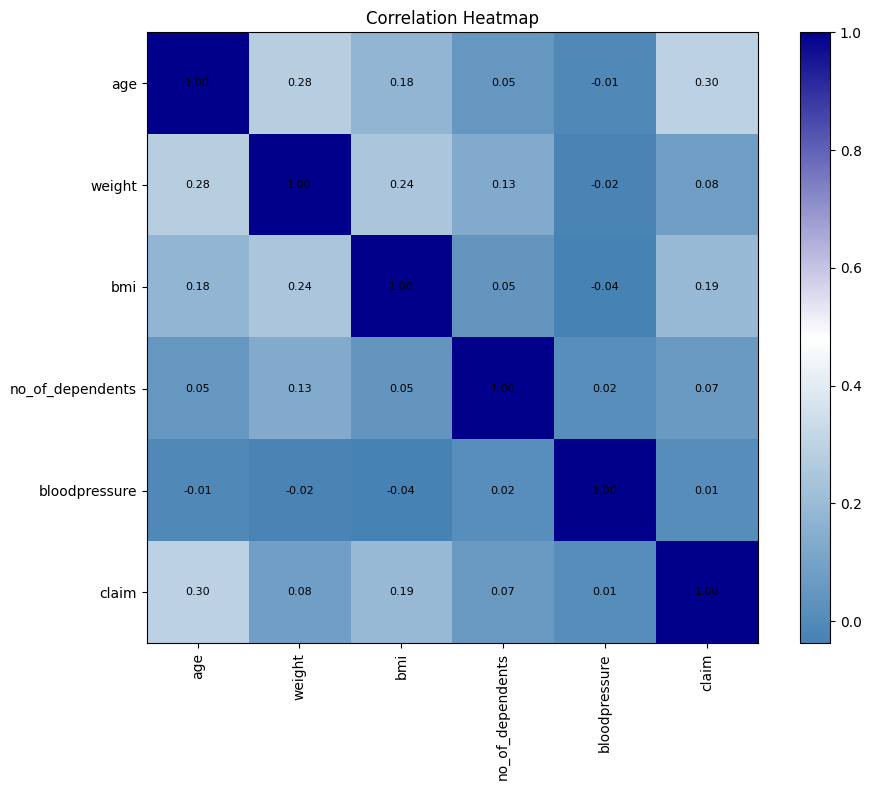

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

# Correlation matrix for Insurance dataset
corr = df[['age', 'weight', 'bmi', 'no_of_dependents',
           'bloodpressure', 'claim']].corr()

# Custom Light Blue to Orange colormap
custom_cmap = LinearSegmentedColormap.from_list(
    "blue_orange",
    ["steelblue", "white", "darkblue"]
)

plt.figure(figsize=(10,8))

plt.imshow(corr, cmap=custom_cmap)
plt.colorbar()

plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)

# Values inside boxes
for i in range(len(corr)):
    for j in range(len(corr.columns)):
        plt.text(j, i, f"{corr.iloc[i,j]:.2f}",
                 ha='center', va='center', fontsize=8)

plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

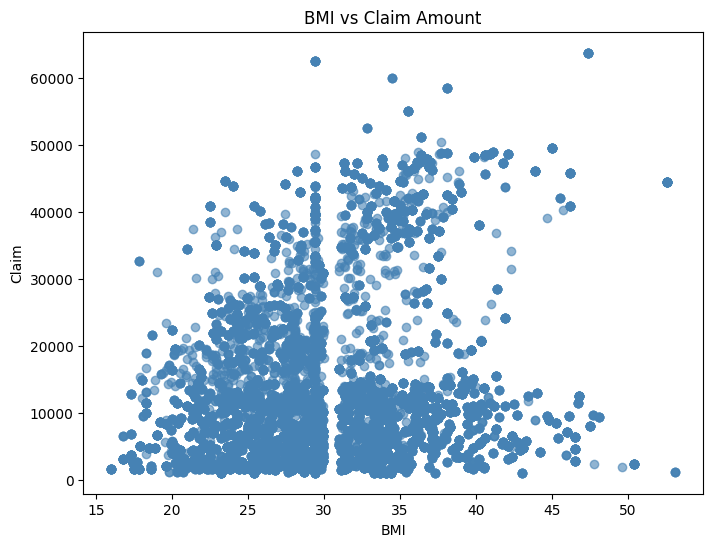

In [ ]:
import matplotlib.pyplot as plt

# Scatter plot for Insurance dataset
# BMI vs Claim Amount

plt.figure(figsize=(8,6))
plt.scatter(df['bmi'], df['claim'], alpha=0.6, color='steelblue')

plt.xlabel("BMI")
plt.ylabel("Claim")
plt.title("BMI vs Claim Amount")

plt.show()


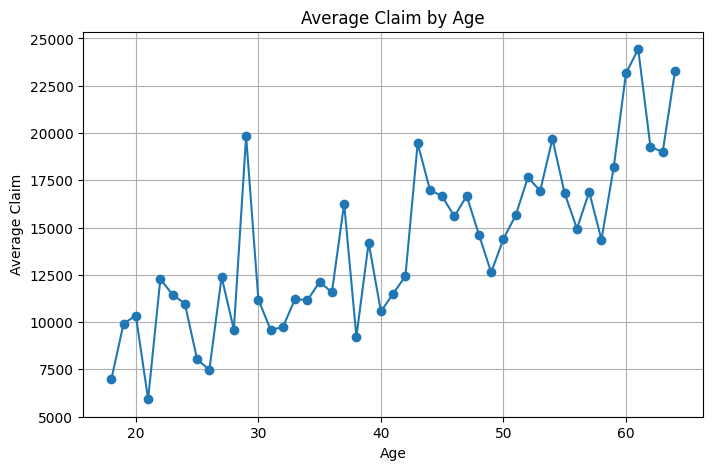

In [ ]:
import matplotlib.pyplot as plt

# Average claim by age
avg_claim_age = df.groupby('age')['claim'].mean()

plt.figure(figsize=(8,5))
plt.plot(avg_claim_age.index, avg_claim_age.values, marker='o')

plt.title("Average Claim by Age")
plt.xlabel("Age")
plt.ylabel("Average Claim")

plt.grid(True)
plt.show()

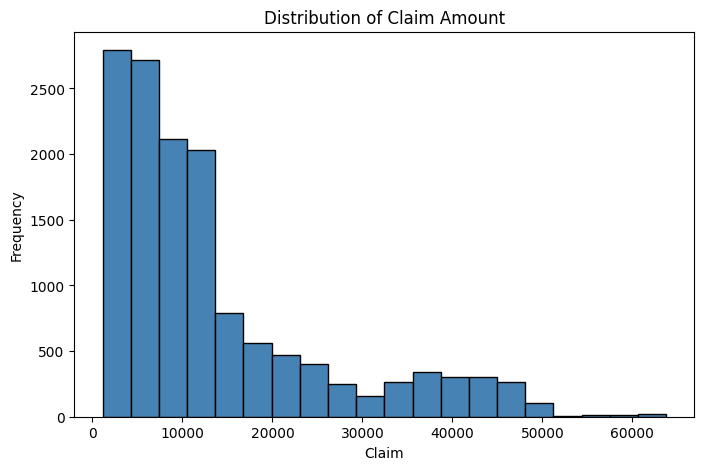

In [ ]:
import matplotlib.pyplot as plt

# Claim distribution
plt.figure(figsize=(8,5))
plt.hist(
    df['claim'],
    bins=20,
    color='steelblue',
    edgecolor='black'
)

plt.title("Distribution of Claim Amount")
plt.xlabel("Claim")
plt.ylabel("Frequency")

plt.show()

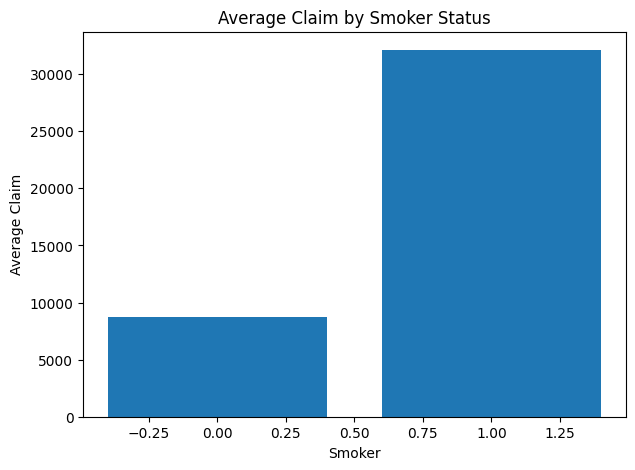

In [ ]:
# 2. Average claim by smoker
avg_claim = df.groupby('smoker')['claim'].mean()

plt.figure(figsize=(7,5))
plt.bar(avg_claim.index, avg_claim.values)
plt.title("Average Claim by Smoker Status")
plt.xlabel("Smoker")
plt.ylabel("Average Claim")
plt.show()

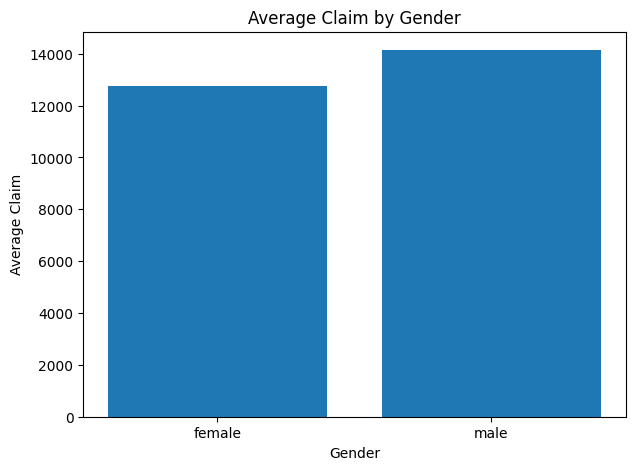

In [ ]:
# 3. Claim by gender
avg_claim_gender = df.groupby('sex')['claim'].mean()

plt.figure(figsize=(7,5))
plt.bar(avg_claim_gender.index, avg_claim_gender.values)
plt.title("Average Claim by Gender")
plt.xlabel("Gender")
plt.ylabel("Average Claim")
plt.show()

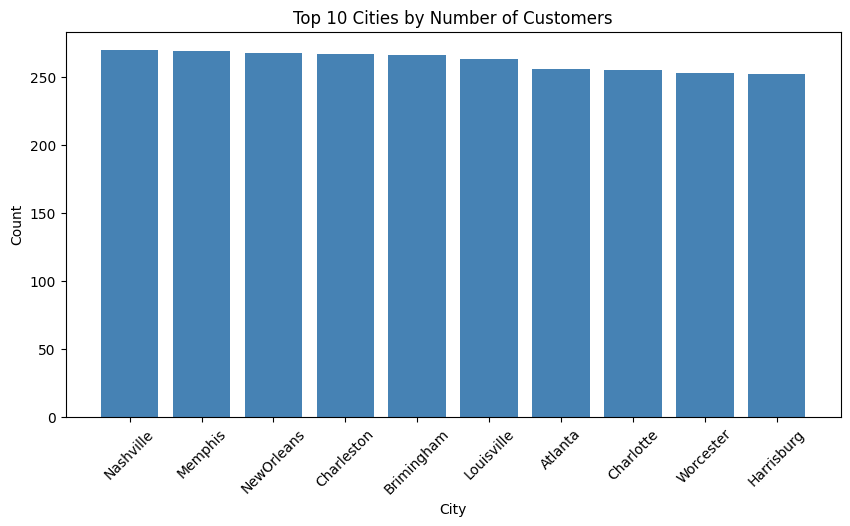

In [ ]:
# 6. Claims by city (Top 10) with lavender color

top_city = df['city'].value_counts().head(10)

plt.figure(figsize=(10,5))
plt.bar(top_city.index, top_city.values, color='steelblue')

plt.title("Top 10 Cities by Number of Customers")
plt.xlabel("City")
plt.ylabel("Count")

plt.xticks(rotation=45)
plt.show()

#**Feature Selection**

In [ ]:
# Set target column for YOUR insurance dataset

target = 'claim'

# Features and target split
X = df.drop(columns=[target])
y = df[target]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (13904, 12)
Target shape: (13904,)


In [ ]:
# Keep only numeric columns for feature selection (YOUR insurance dataset)

X_numeric = X.select_dtypes(include=['int64', 'float64'])

print("Numeric features:")
print(X_numeric.columns)

Numeric features:
Index(['age', 'weight', 'bmi', 'no_of_dependents', 'smoker', 'bloodpressure',
       'diabetes', 'regular_ex'],
      dtype='object')


In [ ]:
import numpy as np

# Target column for YOUR insurance dataset
target = 'claim'

# Compute correlation with target
corr_with_target = df.corr(numeric_only=True)[target].abs().sort_values(ascending=False)

print("Correlation with target:")
print(corr_with_target)

# Select features with correlation > threshold
threshold = 0.3
selected_corr_features = corr_with_target[corr_with_target > threshold].index.tolist()

# Remove target itself
if target in selected_corr_features:
    selected_corr_features.remove(target)

print("\nSelected Features (Correlation-based):")
print(selected_corr_features)

Correlation with target:
claim               1.000000
smoker              0.770423
age                 0.297310
bmi                 0.194117
diabetes            0.134828
weight              0.081815
no_of_dependents    0.067536
regular_ex          0.060346
bloodpressure       0.012168
Name: claim, dtype: float64

Selected Features (Correlation-based):
['smoker']


In [ ]:
from sklearn.feature_selection import SelectKBest, f_regression

# Use numeric columns from YOUR insurance dataset
X_numeric = X.select_dtypes(include=['int64', 'float64'])

# Initialize selector
selector = SelectKBest(score_func=f_regression, k=5)

# Fit selector
X_new = selector.fit_transform(X_numeric, y)

# Get selected feature names
selected_kbest_features = X_numeric.columns[selector.get_support()]

print("Selected Features (SelectKBest):")
print(selected_kbest_features)

Selected Features (SelectKBest):
Index(['age', 'weight', 'bmi', 'smoker', 'diabetes'], dtype='object')


In [ ]:
from sklearn.ensemble import RandomForestRegressor
import pandas as pd

# Use numeric features from YOUR insurance dataset
X_numeric = X.select_dtypes(include=['int64', 'float64'])

# Train model
model = RandomForestRegressor(random_state=42)
model.fit(X_numeric, y)

# Feature importance
importances = model.feature_importances_

feature_importance_df = pd.DataFrame({
    'Feature': X_numeric.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print("Feature Importance Ranking:")
display(feature_importance_df)

Feature Importance Ranking:


,Feature,Importance
4,smoker,0.594881
2,bmi,0.140240
0,age,0.126250
1,weight,0.044526
5,bloodpressure,0.041100
6,diabetes,0.024202
3,no_of_dependents,0.019821
7,regular_ex,0.008979


#**Train Test Split**

In [ ]:
from sklearn.model_selection import train_test_split

# Target column for YOUR insurance dataset
target = 'claim'

# Features and target
X = df.drop(columns=[target])
y = df[target]

# Keep only numeric columns
X = X.select_dtypes(include=['int64', 'float64'])

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,      # 80% train, 20% test
    random_state=42,    # reproducibility
    shuffle=True
)

print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape :", y_test.shape)

X_train shape: (11123, 8)
X_test shape : (2781, 8)
y_train shape: (11123,)
y_test shape : (2781,)


#**Model Selection**

###**Linear Regression**

[16176.07622374 13252.6139802  12317.33303904 12146.08503703
  8865.37799349 34342.24462724 32390.55809843  7680.8959899
 37551.40857089 12972.35956325]


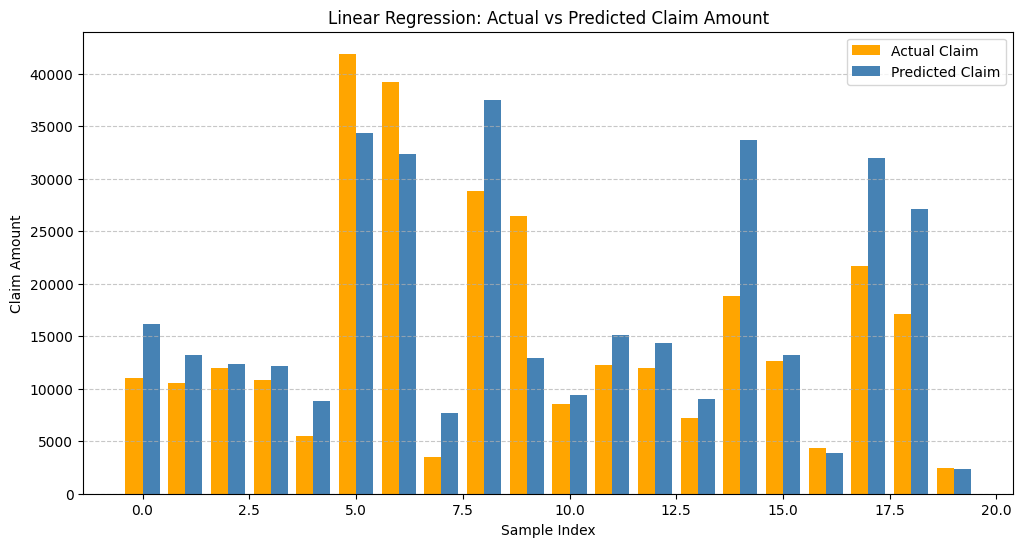

In [ ]:
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import numpy as np

# Linear Regression for Insurance dataset

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Predictions
lr_predictions = lr_model.predict(X_test)

print(lr_predictions[:10])

# Better Visualization: Actual vs Predicted Bar Chart

n = 20   # first 20 samples

x = np.arange(n)

plt.figure(figsize=(12,6))

plt.bar(x - 0.2, y_test.values[:n], width=0.4, label='Actual Claim', color='orange')
plt.bar(x + 0.2, lr_predictions[:n], width=0.4, label='Predicted Claim', color='steelblue')

plt.title("Linear Regression: Actual vs Predicted Claim Amount")
plt.xlabel("Sample Index")
plt.ylabel("Claim Amount")

plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

###**Decesion Tree**

[10982.5 10560.5 11931.1 10807.5  5488.3 41919.1 39241.4  3500.6 28868.7
 26467.1]


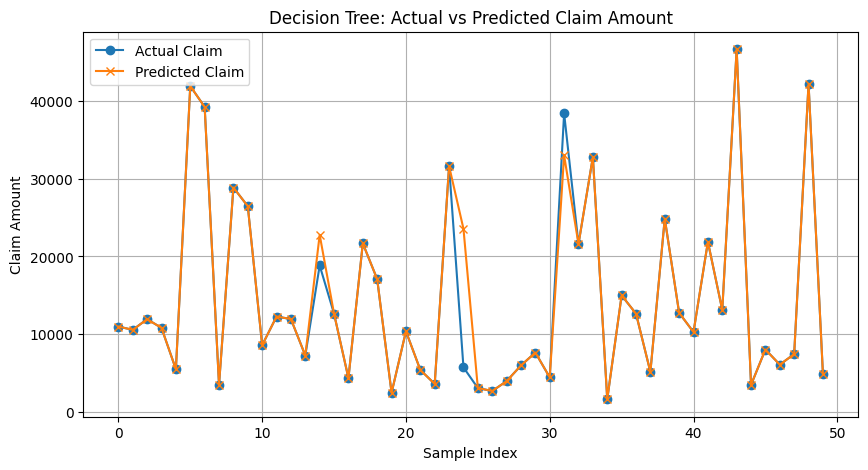

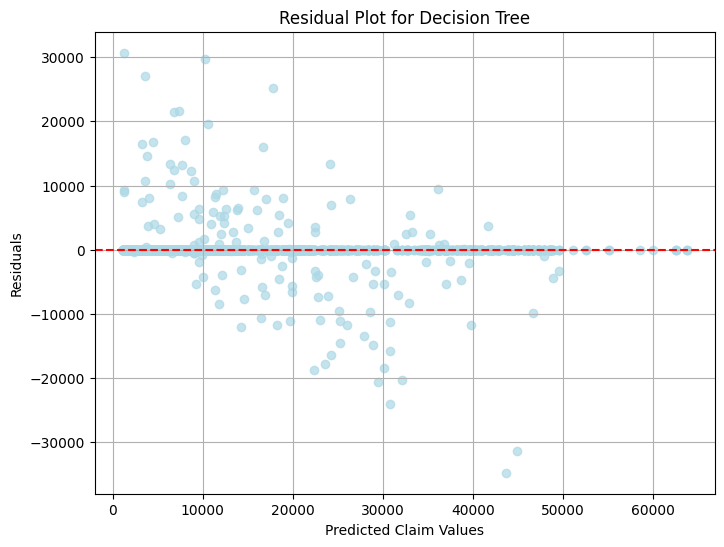

In [ ]:
from sklearn.tree import DecisionTreeRegressor
import matplotlib.pyplot as plt

# Decision Tree Regressor for Insurance dataset

dt_model = DecisionTreeRegressor(random_state=42)
dt_model.fit(X_train, y_train)

# Predictions
dt_predictions = dt_model.predict(X_test)

print(dt_predictions[:10])

# Better Visualization: Line Plot (Actual vs Predicted)

plt.figure(figsize=(10,5))

plt.plot(y_test.values[:50], label='Actual Claim', marker='o')
plt.plot(dt_predictions[:50], label='Predicted Claim', marker='x')

plt.title("Decision Tree: Actual vs Predicted Claim Amount")
plt.xlabel("Sample Index")
plt.ylabel("Claim Amount")

plt.legend()
plt.grid(True)
plt.show()


# Residual Plot
residuals = y_test - dt_predictions

plt.figure(figsize=(8,6))
plt.scatter(dt_predictions, residuals, alpha=0.7, color='lightblue')

plt.axhline(y=0, color='red', linestyle='--')

plt.xlabel("Predicted Claim Values")
plt.ylabel("Residuals")
plt.title("Residual Plot for Decision Tree")

plt.grid(True)
plt.show()

###**KNN**

Predicted Claim Values: [12927.8  10560.5  11931.1  10807.5   9024.42 24114.92 39241.4   3500.6
 28868.7  26467.1 ]


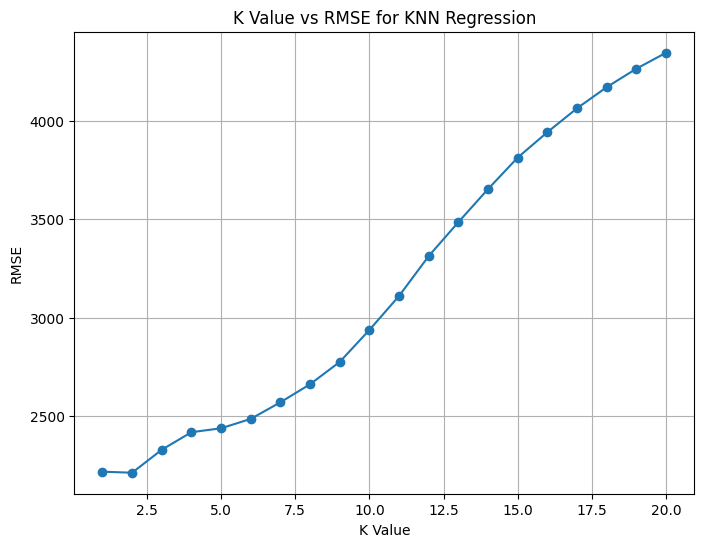

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error
import numpy as np
import matplotlib.pyplot as plt

# KNN Regression for YOUR insurance dataset

# Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train KNN
model_knn = KNeighborsRegressor(n_neighbors=5)
model_knn.fit(X_train_scaled, y_train)

# Predict
y_pred_knn = model_knn.predict(X_test_scaled)

print("Predicted Claim Values:", y_pred_knn[:10])

# K vs RMSE
k_values = range(1, 21)
rmse = []

for k in k_values:
    knn = KNeighborsRegressor(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    pred = knn.predict(X_test_scaled)
    rmse.append(np.sqrt(mean_squared_error(y_test, pred)))

# Plot
plt.figure(figsize=(8,6))
plt.plot(k_values, rmse, marker='o')

plt.xlabel("K Value")
plt.ylabel("RMSE")
plt.title("K Value vs RMSE for KNN Regression")

plt.grid(True)
plt.show()

###**Gradient Boosting**

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor

# Gradient Boosting Regressor for YOUR insurance dataset

model_gbr = GradientBoostingRegressor(random_state=42)

# Train model
model_gbr.fit(X_train, y_train)

# Predict claim values
y_pred_gbr = model_gbr.predict(X_test)

print("Gradient Boosting Predicted Claim Values:")
print(y_pred_gbr[:10])

Gradient Boosting Predicted Claim Values:
[13031.45356259 11229.74701128 12175.12483084 14278.80524793
  7326.0723395  38461.49344146 40496.86626589  6681.7741002
 30386.25947844 14695.1056703 ]


###**Random Forest**

In [ ]:
from sklearn.ensemble import RandomForestRegressor

# Random Forest Regressor for YOUR insurance dataset

model_rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

# Train model
model_rf.fit(X_train, y_train)

# Predict claim values
y_pred_rf = model_rf.predict(X_test)

print("Random Forest Predicted Claim Values:")
print(y_pred_rf[:10])

Random Forest Predicted Claim Values:
[10983.582 10560.5   11931.1   10807.5    5916.611 38572.896 39241.4
  3500.6   28868.7   26467.1  ]


###**XG Boost**

In [ ]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
import numpy as np

# XGBoost Regressor for YOUR insurance dataset

model_xgb = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=4,
    random_state=42
)

# Train model
model_xgb.fit(X_train, y_train)

# Predict
y_pred_xgb = model_xgb.predict(X_test)

print("XGBoost Predicted Claim Values:")
print(y_pred_xgb[:10])

# Evaluation
mae = mean_absolute_error(y_test, y_pred_xgb)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
r2 = r2_score(y_test, y_pred_xgb)

print("\nXGBoost Performance:")
print("MAE :", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

XGBoost Predicted Claim Values:
[12823.453  10925.466  11455.966  13621.963   6766.3745 38203.547
 41036.44    6521.032  29861.09   15989.815 ]

XGBoost Performance:
MAE : 2585.2852414665786
RMSE: 4379.029308730447
R2 Score: 0.8718580985982296


##**Model Training & Testing**

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor
from xgboost import XGBRegressor
import pandas as pd
import numpy as np

# Target column for YOUR insurance dataset
target = 'claim'

# Prepare features and target
X = df.drop(columns=[target]).select_dtypes(include=['int64', 'float64'])
y = df[target].loc[X.index]

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Initialize models
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42),
    "KNeighbour Regressor": KNeighborsRegressor(n_neighbors=5),
    "XGBoost Regressor": XGBRegressor(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=4,
        random_state=42
    )
}

# Train and Evaluate
results = []

for name, model in models.items():

    # Train model
    model.fit(X_train, y_train)

    # Predict
    y_pred = model.predict(X_test)

    # Metrics
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    # Store results
    results.append({
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2 Score": r2
    })

# Convert to DataFrame
results_df = pd.DataFrame(results)

# Show sorted results
print("Model Performance Comparison:")
print(results_df.sort_values(by="R2 Score", ascending=False))

Model Performance Comparison:
                  Model          MAE         RMSE  R2 Score
2         Random Forest   383.820520  2009.319335  0.973021
1         Decision Tree   421.058420  2449.949053  0.959890
4  KNeighbour Regressor   847.419986  3496.216086  0.918317
5     XGBoost Regressor  2585.285241  4379.029309  0.871858
3     Gradient Boosting  3003.600239  4960.007623  0.835601
0     Linear Regression  4468.655469  6541.503274  0.714050


In [42]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', RandomForestRegressor(
        n_estimators=100,
        random_state=42
    ))
])

pipeline.fit(X_train, y_train)

y_pred = pipeline.predict(X_test)

print("Pipeline R2 Score:", r2_score(y_test, y_pred))

Pipeline R2 Score: 0.9727351802983077


##**Performance Evaluation**

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor
from xgboost import XGBRegressor

# Initialize models for YOUR insurance dataset
lr_model = LinearRegression()
dt_model = DecisionTreeRegressor(random_state=42)
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
gb_model = GradientBoostingRegressor(random_state=42)
knn_model = KNeighborsRegressor(n_neighbors=5)

xgb_model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=4,
    random_state=42
)

# Train models
lr_model.fit(X_train, y_train)
dt_model.fit(X_train, y_train)
rf_model.fit(X_train, y_train)
gb_model.fit(X_train, y_train)
knn_model.fit(X_train, y_train)
xgb_model.fit(X_train, y_train)

# Predictions
lr_predictions  = lr_model.predict(X_test)
dt_predictions  = dt_model.predict(X_test)
rf_predictions  = rf_model.predict(X_test)
gb_predictions  = gb_model.predict(X_test)
knn_predictions = knn_model.predict(X_test)
xgb_predictions = xgb_model.predict(X_test)

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import pandas as pd
import numpy as np

results = []

models_predictions = {}

# Train all models and store predictions
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    models_predictions[name] = y_pred

# Evaluate all models
for name, y_pred in models_predictions.items():

    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    results.append({
        "Model": name,
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "R2 Score": r2
    })

# Results DataFrame
results_df = pd.DataFrame(results)

# Display sorted results
display(results_df.sort_values(by="R2 Score", ascending=False))

,Model,MAE,MSE,RMSE,R2 Score
2,Random Forest,383.820520,4.037364e+06,2009.319335,0.973021
1,Decision Tree,421.058420,6.002250e+06,2449.949053,0.959890
4,KNeighbour Regressor,847.419986,1.222353e+07,3496.216086,0.918317
5,XGBoost Regressor,2585.285241,1.917590e+07,4379.029309,0.871858
3,Gradient Boosting,3003.600239,2.460168e+07,4960.007623,0.835601
0,Linear Regression,4468.655469,4.279127e+07,6541.503274,0.714050


##**Hyperparameter Tuning**

In [41]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

# Random Forest Hyperparameter Tuning for Health Insurance Dataset

# Base Model
rf = RandomForestRegressor(random_state=42)

# Parameter Grid
param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt', 'log2']
}

# Grid Search CV
grid_rf = GridSearchCV(
    estimator=rf,
    param_grid=param_grid_rf,
    cv=3,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)

# Train Grid Search
grid_rf.fit(X_train, y_train)

# Best Model
best_rf = grid_rf.best_estimator_

# Best Parameters
print("Best Parameters (Random Forest):")
print(grid_rf.best_params_)

# Predictions
y_pred_rf = best_rf.predict(X_test)

# Evaluation
r2 = r2_score(y_test, y_pred_rf)
mae = mean_absolute_error(y_test, y_pred_rf)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))

print("\nTuned Random Forest Performance:")
print("R2 Score :", r2)
print("MAE      :", mae)
print("RMSE     :", rmse)

Fitting 3 folds for each of 48 candidates, totalling 144 fits
Best Parameters (Random Forest):
{'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}

Tuned Random Forest Performance:
R2 Score : 0.9742947548668816
MAE      : 371.00860711552076
RMSE     : 1961.296010277531


##**Results**

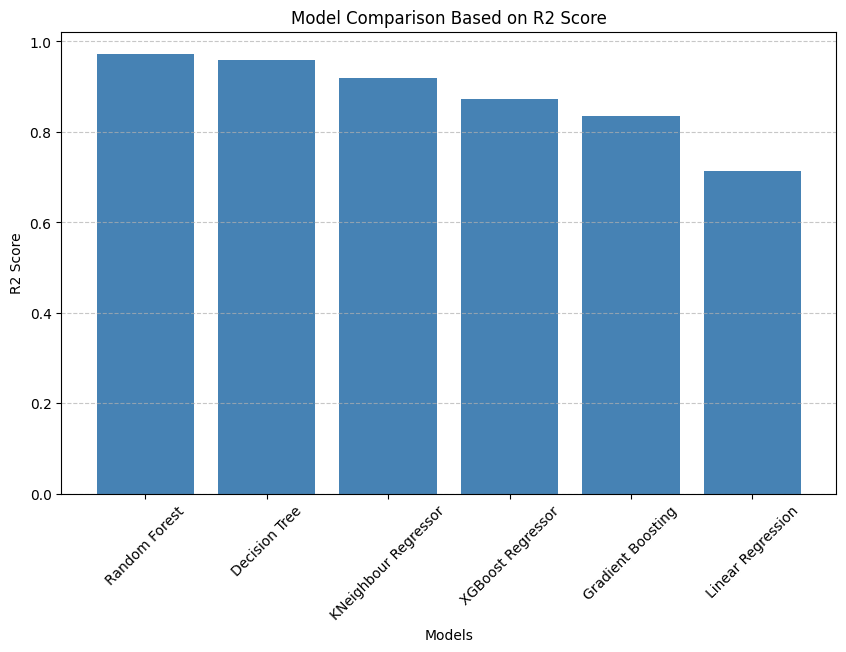

In [43]:
import matplotlib.pyplot as plt

# Model Comparison Graph using R2 Score

sorted_df = results_df.sort_values(by="R2 Score", ascending=False)

plt.figure(figsize=(10,6))
plt.bar(sorted_df["Model"], sorted_df["R2 Score"], color='steelblue')

plt.title("Model Comparison Based on R2 Score")
plt.xlabel("Models")
plt.ylabel("R2 Score")

plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

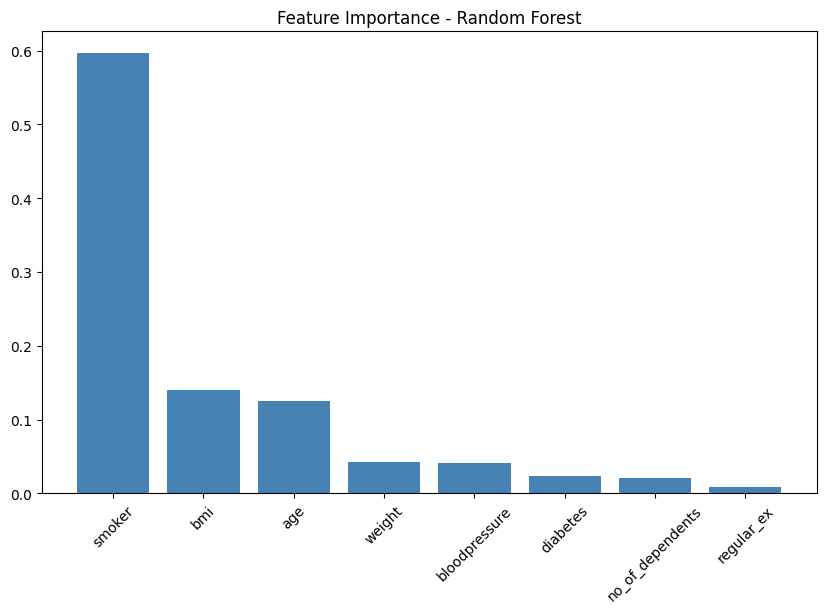

In [44]:
import pandas as pd
import matplotlib.pyplot as plt

importance = rf_model.feature_importances_

feat_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': importance
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10,6))
plt.bar(feat_df['Feature'], feat_df['Importance'], color='steelblue')
plt.xticks(rotation=45)
plt.title("Feature Importance - Random Forest")
plt.show()

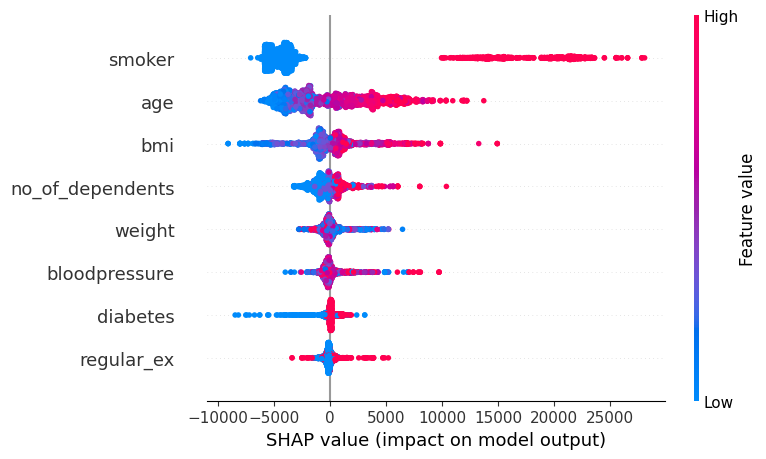

In [47]:
import shap

explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test)

In [45]:
import joblib

# Save Best Model (Random Forest)

joblib.dump(rf_model, 'best_insurance_model.pkl')

print("Model saved successfully as best_insurance_model.pkl")

Model saved successfully as best_insurance_model.pkl


###**Conclusion**
This project successfully developed a machine learning model for predicting health insurance claim amounts using customer demographic and health-related factors.

Among all regression models tested, Random Forest Regressor achieved the best performance with the highest R² score and lowest prediction error.

Feature importance analysis showed that smoker status, BMI, and age were the most influential factors affecting claim cost.

The final model can help insurance companies improve premium pricing, risk assessment, and cost estimation.